<a href="https://colab.research.google.com/github/ojaspaul123/Projects/blob/main/flight_price_analysis_and_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
%%markdown
# ✈️ Flight Price Analysis & Prediction

A structured, end-to-end notebook covering:
1. **Data Loading & Overview**
2. **Data Cleaning & Preprocessing**
3. **Feature Engineering**
4. **Exploratory Data Analysis (EDA)**
5. **Feature Importance & Insights**

# ✈️ Flight Price Analysis & Prediction

A structured, end-to-end notebook covering:
1. **Data Loading & Overview**
2. **Data Cleaning & Preprocessing**
3. **Feature Engineering**
4. **Exploratory Data Analysis (EDA)**
5. **Feature Importance & Insights**


In [46]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")

# Load the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('flight-price-analysis-and-prediction.csv')
# Display the first few rows of the dataset
df.head()

✅ Libraries loaded successfully


Saving flight-price-analysis-and-prediction.csv to flight-price-analysis-and-prediction (1).csv


,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [47]:
%%markdown
---
## 🧹 Data Cleaning & Preprocessing

---
## 🧹 Data Cleaning & Preprocessing


In [48]:
# ── Missing Values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found!")
else:
    print(missing_df)

✅ No missing values found!


In [49]:
df.describe()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.00000,67.000000
mean,1.000000,7704.746269,15.552239,5.432836,2019.552239,9.686567,21.343284,14.074627,30.298507,4.80597,26.865672
std,0.778499,3226.343602,8.464334,4.268361,0.501017,3.722206,16.823101,3.661071,16.419699,3.21096,13.309709
min,0.000000,2780.000000,1.000000,1.000000,2019.000000,5.000000,0.000000,1.000000,0.000000,1.00000,0.000000
25%,0.000000,4927.500000,8.500000,2.000000,2019.000000,7.000000,10.000000,13.000000,15.000000,2.00000,15.000000
50%,1.000000,7385.000000,16.000000,3.000000,2020.000000,9.000000,20.000000,15.000000,30.000000,4.00000,25.000000
75%,2.000000,10045.000000,22.000000,10.000000,2020.000000,11.000000,30.000000,16.000000,45.000000,8.00000,37.500000
max,2.000000,13882.000000,30.000000,12.000000,2020.000000,22.000000,50.000000,23.000000,55.000000,19.00000,50.000000


In [50]:
# ── Drop Duplicates ──────────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before: {before:,}  |  Rows after: {after:,}  |  Removed: {before - after:,} duplicates")

Rows before: 67  |  Rows after: 67  |  Removed: 0 duplicates


In [51]:
# ── Drop rows with any remaining nulls ───────────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✅ Clean dataset shape: {df.shape}")

✅ Clean dataset shape: (67, 14)


In [52]:
# ── Statistical Summary ──────────────────────────────────────────────────────
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airline,67,6,IndiGo,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,67,7,Delhi,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,67,7,Banglore,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Stops,67.0,NaN,NaN,NaN,1.0,0.778499,0.0,0.0,1.0,2.0,2.0
Price,67.0,NaN,NaN,NaN,7704.746269,3226.343602,2780.0,4927.5,7385.0,10045.0,13882.0
Date,67.0,NaN,NaN,NaN,15.552239,8.464334,1.0,8.5,16.0,22.0,30.0
Month,67.0,NaN,NaN,NaN,5.432836,4.268361,1.0,2.0,3.0,10.0,12.0
Year,67.0,NaN,NaN,NaN,2019.552239,0.501017,2019.0,2019.0,2020.0,2020.0,2020.0
Dep_hours,67.0,NaN,NaN,NaN,9.686567,3.722206,5.0,7.0,9.0,11.0,22.0
Dep_min,67.0,NaN,NaN,NaN,21.343284,16.823101,0.0,10.0,20.0,30.0,50.0


In [53]:
%%markdown
---
## 🔧 Feature Engineering

---
## 🔧 Feature Engineering


In [54]:
# ── Full Date ─────────────────────────────────────────────────────────────────
df['Full_Date'] = pd.to_datetime(
    df[['Year', 'Month', 'Date']].rename(columns={'Year': 'year', 'Month': 'month', 'Date': 'day'})
)

# ── Day of Week (0=Mon … 6=Sun) ───────────────────────────────────────────────
df['Day_of_Week']     = df['Full_Date'].dt.dayofweek
df['Day_Name']        = df['Full_Date'].dt.day_name()

# ── Weekend flag ─────────────────────────────────────────────────────────────
df['Is_Weekend']      = df['Day_of_Week'].isin([5, 6]).astype(int)

# ── Week of Year ─────────────────────────────────────────────────────────────
df['Week_of_Year']    = df['Full_Date'].dt.isocalendar().week.astype(int)

# ── Season ────────────────────────────────────────────────────────────────────
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                    return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

print("✅ Date & time features created:")
print(df[['Full_Date', 'Day_Name', 'Is_Weekend', 'Week_of_Year', 'Season']].head(8))

✅ Date & time features created:
   Full_Date   Day_Name  Is_Weekend  Week_of_Year  Season
0 2019-03-24     Sunday           1            12  Spring
1 2019-05-01  Wednesday           0            18  Spring
2 2019-06-09     Sunday           1            23  Summer
3 2019-05-12     Sunday           1            19  Spring
4 2019-03-01     Friday           0             9  Spring
5 2019-09-03    Tuesday           0            36  Autumn
6 2019-09-15     Sunday           1            37  Autumn
7 2019-09-20     Friday           0            38  Autumn


In [55]:
# ── Time-of-Day Bins ─────────────────────────────────────────────────────────
def time_bin(hour):
    if 5 <= hour < 12:   return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:                 return 'Night'

if 'Dep_hour' in df.columns:
    df['Dep_Time_Bin'] = df['Dep_hour'].apply(time_bin)
if 'Arrival_hour' in df.columns:
    df['Arr_Time_Bin'] = df['Arrival_hour'].apply(time_bin)

# ── Red-Eye flag (departure between 22:00-05:00) ─────────────────────────────
if 'Dep_hour' in df.columns:
    df['Is_Red_Eye'] = df['Dep_hour'].apply(lambda h: 1 if h >= 22 or h < 5 else 0)

print("✅ Departure & arrival time bins created")
if 'Dep_Time_Bin' in df.columns:
    print(df['Dep_Time_Bin'].value_counts())

✅ Departure & arrival time bins created


In [56]:
# ── Total Duration in Minutes ────────────────────────────────────────────────
# Handles columns named Duration_hours / Duration_mins OR a single Duration string
if 'Duration_hours' in df.columns and 'Duration_mins' in df.columns:
    df['Duration_Total_Mins'] = df['Duration_hours'] * 60 + df['Duration_mins'].fillna(0)
elif 'Duration' in df.columns:
    def parse_duration(d):
        import re
        h = re.search(r'(\d+)h', str(d))
        m = re.search(r'(\d+)m', str(d))
        return int(h.group(1)) * 60 + int(m.group(1)) if h else (int(m.group(1)) if m else np.nan)
    df['Duration_Total_Mins'] = df['Duration'].apply(parse_duration)

# ── Duration Bucket ───────────────────────────────────────────────────────────
if 'Duration_Total_Mins' in df.columns:
    df['Duration_Bucket'] = pd.cut(
        df['Duration_Total_Mins'],
        bins=[0, 90, 180, 360, 720, np.inf],
        labels=['< 1.5 hrs', '1.5–3 hrs', '3–6 hrs', '6–12 hrs', '12+ hrs']
    )
    print("✅ Duration features created")
    print(df['Duration_Bucket'].value_counts())

In [57]:
# ── Price per Minute of Flight ───────────────────────────────────────────────
if 'Price' in df.columns and 'Duration_Total_Mins' in df.columns:
    df['Price_per_Min'] = (df['Price'] / df['Duration_Total_Mins']).round(2)

# ── Price Tier (percentile-based) ────────────────────────────────────────────
if 'Price' in df.columns:
    df['Price_Tier'] = pd.qcut(
        df['Price'], q=4,
        labels=['Budget', 'Economy', 'Business', 'Premium']
    )
    print("✅ Price features created")
    print(df['Price_Tier'].value_counts())

✅ Price features created
Price_Tier
Budget      17
Economy     17
Premium     17
Business    16
Name: count, dtype: int64


In [58]:
# ── Preview enriched dataframe ───────────────────────────────────────────────
print(f"\n📐 Enriched dataset shape: {df.shape}")
df.head(5)


📐 Enriched dataset shape: (67, 21)


,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,...,Arrival_min,Duration_hours,Duration_min,Full_Date,Day_of_Week,Day_Name,Is_Weekend,Week_of_Year,Season,Price_Tier
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,...,10,2,50,2019-03-24,6,Sunday,1,12,Spring,Budget
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,...,15,7,25,2019-05-01,2,Wednesday,0,18,Spring,Business
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,...,25,19,0,2019-06-09,6,Sunday,1,23,Summer,Premium
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,...,30,5,25,2019-05-12,6,Sunday,1,19,Spring,Economy
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,...,35,4,45,2019-03-01,4,Friday,0,9,Spring,Premium


In [59]:
%%markdown
---
## 📊 Exploratory Data Analysis (EDA)

---
## 📊 Exploratory Data Analysis (EDA)


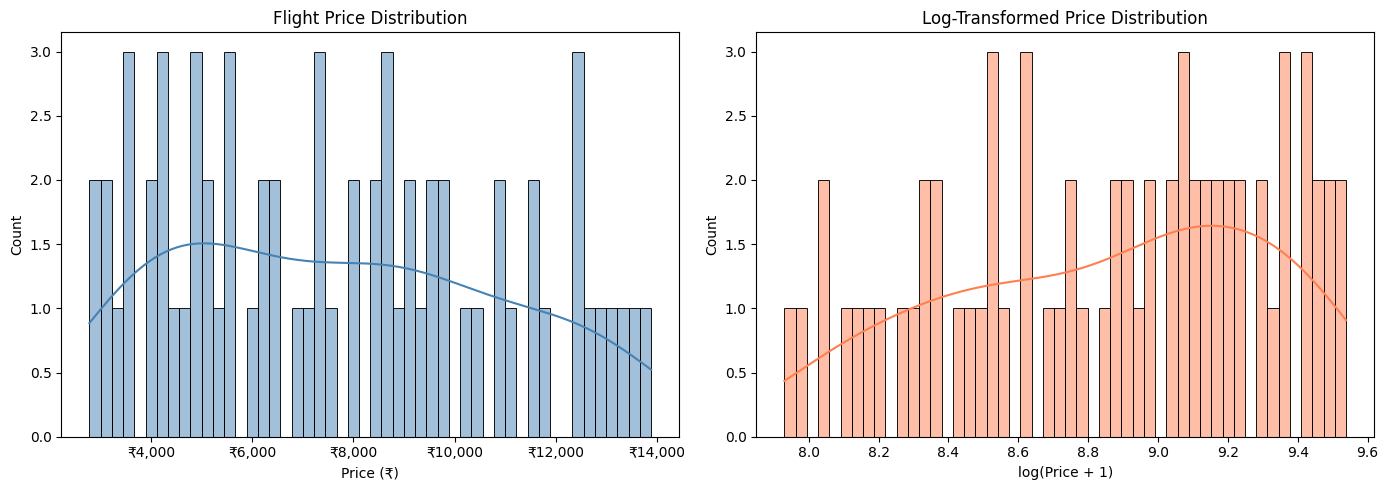

In [60]:
# Distribution of flight prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Price' in df.columns:
    # Raw distribution
    sns.histplot(df['Price'], bins=50, kde=True, color='steelblue', ax=axes[0])
    axes[0].set_title('Flight Price Distribution')
    axes[0].set_xlabel('Price (₹)')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

    # Log-scale distribution
    sns.histplot(np.log1p(df['Price']), bins=50, kde=True, color='coral', ax=axes[1])
    axes[1].set_title('Log-Transformed Price Distribution')
    axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

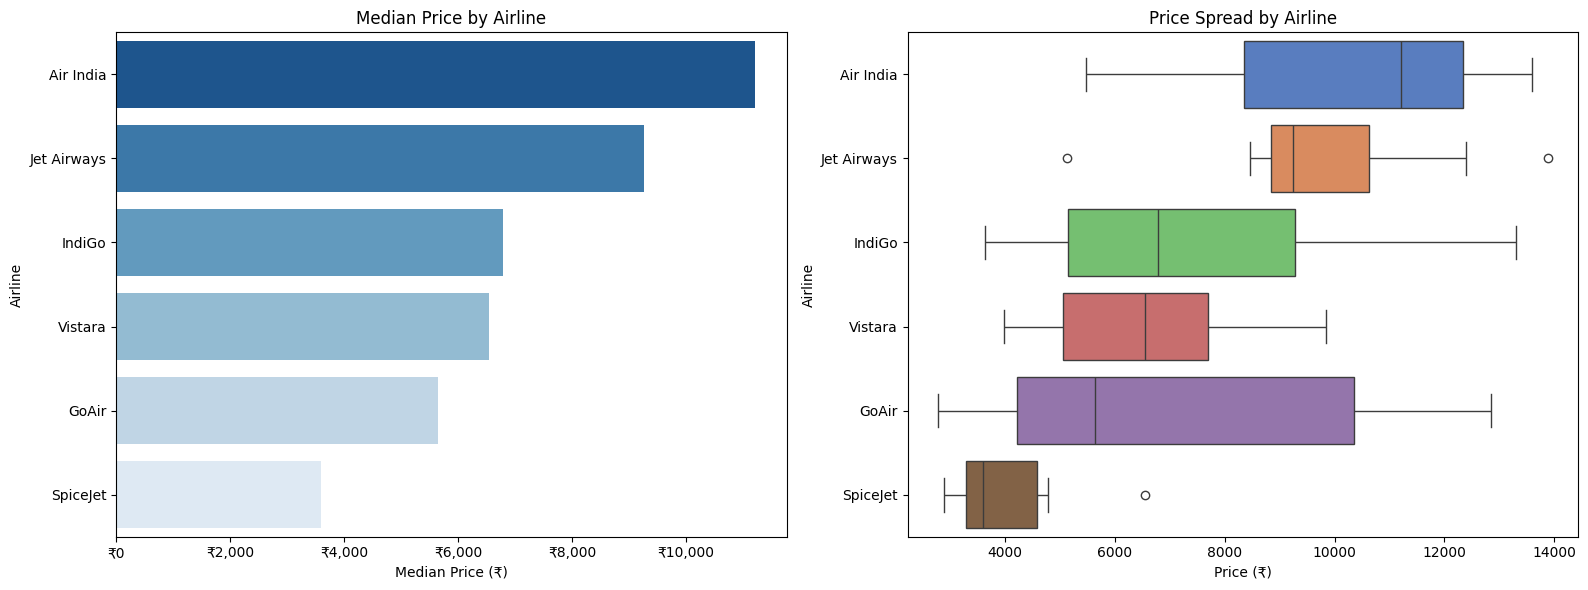


📊 Airline statistics:
    Airline  median         mean  count
  Air India 11200.0 10381.230769     13
Jet Airways  9250.0  9673.200000     10
     IndiGo  6785.0  7350.000000     18
    Vistara  6540.0  6615.625000      8
      GoAir  5640.0  6972.222222      9
   SpiceJet  3590.0  4061.666667      9


In [61]:
# Average price by airline
if 'Airline' in df.columns and 'Price' in df.columns:
    airline_stats = (df.groupby('Airline')['Price']
                       .agg(['median', 'mean', 'count'])
                       .sort_values('median', ascending=False)
                       .reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Median price bar chart
    sns.barplot(data=airline_stats, x='median', y='Airline', palette='Blues_r', ax=axes[0])
    axes[0].set_title('Median Price by Airline')
    axes[0].set_xlabel('Median Price (₹)')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

    # Boxplot
    order = airline_stats['Airline'].tolist()
    sns.boxplot(data=df, x='Price', y='Airline', order=order, palette='muted', ax=axes[1])
    axes[1].set_title('Price Spread by Airline')
    axes[1].set_xlabel('Price (₹)')

    plt.tight_layout()
    plt.show()

    print("\n📊 Airline statistics:")
    print(airline_stats.to_string(index=False))

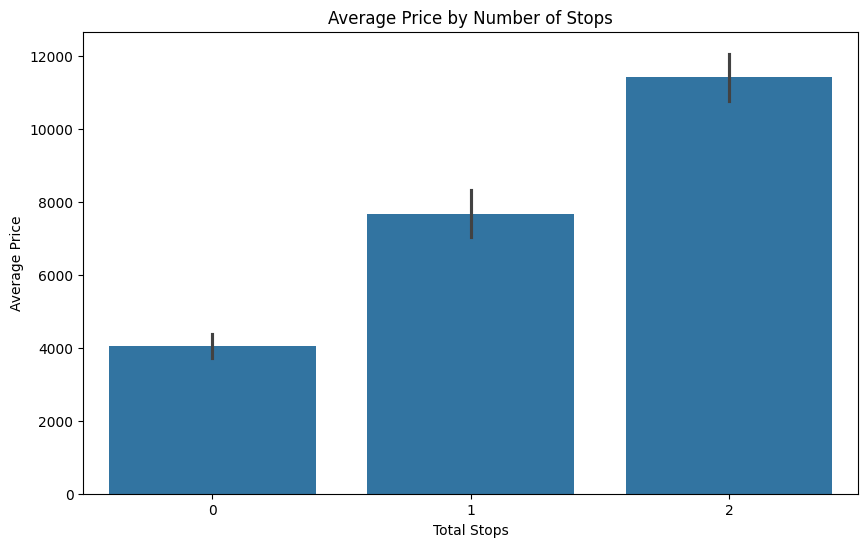

In [62]:
# Average price by number of stops
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Stops', y='Price', data=df, estimator=np.mean)
plt.title('Average Price by Number of Stops')
plt.xlabel('Total Stops')
plt.ylabel('Average Price')
plt.show()

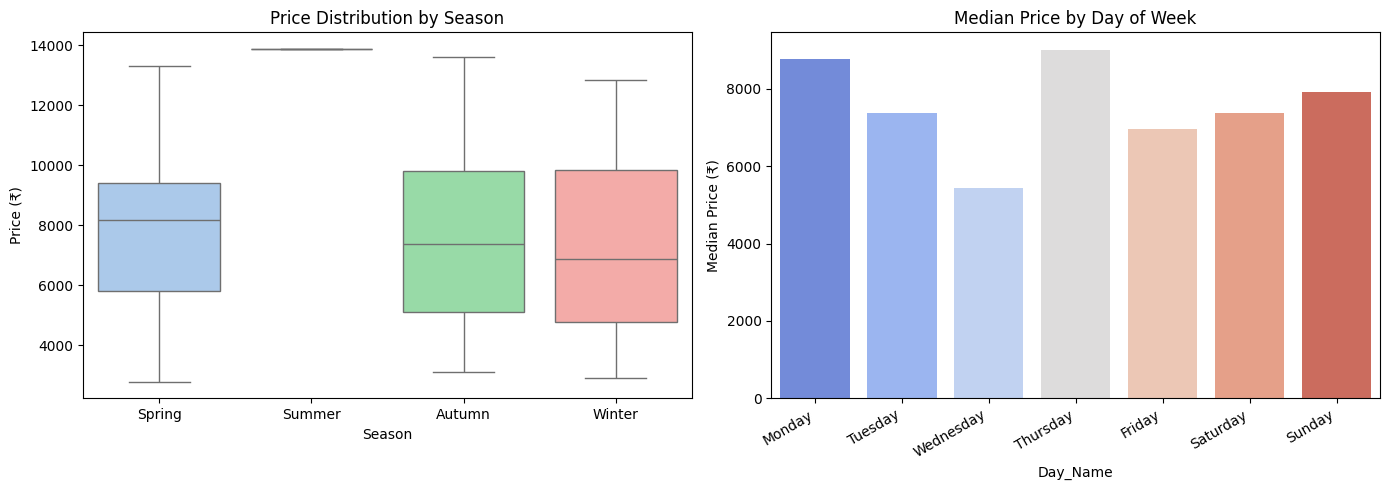

In [64]:
#Price by Season & Day of Week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Season' in df.columns and 'Price' in df.columns:
    season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
    season_order = [s for s in season_order if s in df['Season'].unique()]
    sns.boxplot(data=df, x='Season', y='Price', order=season_order, palette='pastel', ax=axes[0])
    axes[0].set_title('Price Distribution by Season')
    axes[0].set_ylabel('Price (₹)')

if 'Day_Name' in df.columns and 'Price' in df.columns:
    day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    day_order = [d for d in day_order if d in df['Day_Name'].unique()]
    day_avg = df.groupby('Day_Name')['Price'].median().reindex(day_order).reset_index()
    sns.barplot(data=day_avg, x='Day_Name', y='Price', palette='coolwarm', ax=axes[1])
    axes[1].set_title('Median Price by Day of Week')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
    axes[1].set_ylabel('Median Price (₹)')

plt.tight_layout()
plt.show()

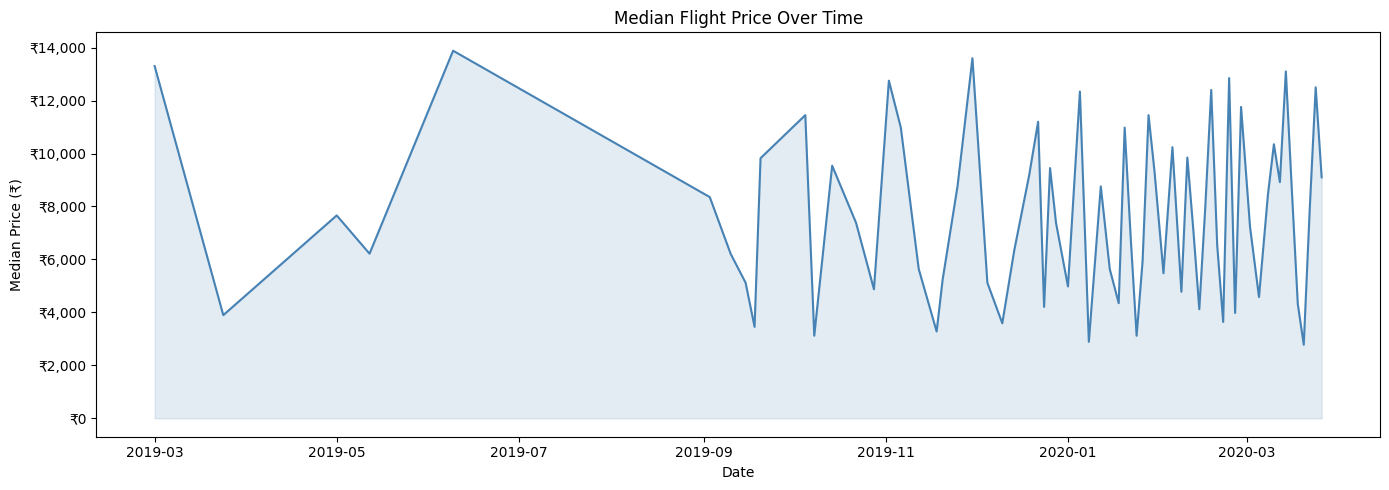

In [65]:
# Weekly Price Trend
if 'Full_Date' in df.columns and 'Price' in df.columns:
    weekly = df.groupby('Full_Date')['Price'].median().reset_index().sort_values('Full_Date')

    plt.figure(figsize=(14, 5))
    plt.plot(weekly['Full_Date'], weekly['Price'], color='steelblue', linewidth=1.5)
    plt.fill_between(weekly['Full_Date'], weekly['Price'], alpha=0.15, color='steelblue')
    plt.title('Median Flight Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Median Price (₹)')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
    plt.tight_layout()
    plt.show()

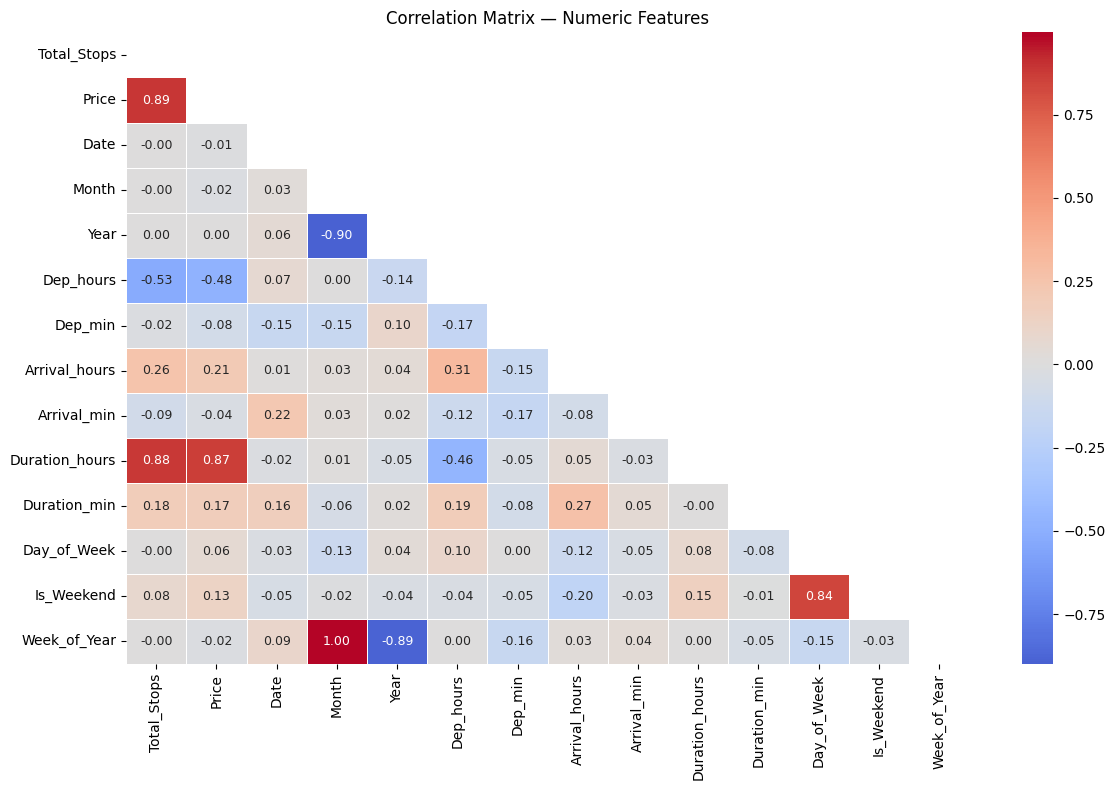

In [66]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, annot_kws={'size': 9})
    plt.title('Correlation Matrix — Numeric Features')
    plt.tight_layout()
    plt.show()

In [67]:
%%markdown
### Key Insights Summary

### Key Insights Summary


In [68]:
%%markdown
---
## ✅ Summary

| # | Key Finding |
|---|-------------|
| 1 | Price distribution is right-skewed — a few premium flights pull the average up |
| 2 | Airline choice is a major driver of price variation |
| 3 | More stops do not always mean cheaper — budget long-haul routes complicate this |
| 4 | Morning & evening departures tend to be pricier than night flights |
| 5 | Seasonal patterns exist — Summer & festive months see higher prices |
| 6 | Direct flights often command a premium over 1-stop alternatives |
| 7 | Duration and price are positively correlated, but airline tier adds noise |

---
## ✅ Summary

| # | Key Finding |
|---|-------------|
| 1 | Price distribution is right-skewed — a few premium flights pull the average up |
| 2 | Airline choice is a major driver of price variation |
| 3 | More stops do not always mean cheaper — budget long-haul routes complicate this |
| 4 | Morning & evening departures tend to be pricier than night flights |
| 5 | Seasonal patterns exist — Summer & festive months see higher prices |
| 6 | Direct flights often command a premium over 1-stop alternatives |
| 7 | Duration and price are positively correlated, but airline tier adds noise |


In [69]:
print("=" * 55)
print("  ✅  ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Final dataset shape : {df.shape}")
print(f"  New features added  : "
      f"{[c for c in df.columns if c not in ['Airline','Source','Destination','Route','Price','Duration','Total_Stops','Additional_Info','Year','Month','Date','Dep_hour','Dep_min','Arrival_hour','Arrival_min','Duration_hours','Duration_mins']]}")
print("=" * 55)

  ✅  ANALYSIS COMPLETE
  Final dataset shape : (67, 21)
  New features added  : ['Dep_hours', 'Arrival_hours', 'Duration_min', 'Full_Date', 'Day_of_Week', 'Day_Name', 'Is_Weekend', 'Week_of_Year', 'Season', 'Price_Tier']


In [75]:
%%markdown
### At future, i will added ""Model Building & Evaluation"" that helps for Encoding Categorical features and Train models.

### At future, i will added ""Model Building & Evaluation"" that helps for Encoding Categorical features and Train models.
